# Modélisation du remboursement anticipé par hasard discret — v2

Cette version corrige deux problèmes identifiés lors du backtesting v1 :

**Problème 1 — delta_star élevé et instable (0.51 à 0.94 selon le fold)**

Le modèle v1 sous-estimait systématiquement le niveau du hasard. La cause principale est l'absence de variable d'incentive macroéconomique. Le hasard de RA est fondamentalement lié à l'écart entre le taux contractuel de l'emprunteur et le taux de marché au moment de l'observation : plus cet écart est élevé, plus l'emprunteur a intérêt à renégocier ou rembourser. Sans cette variable, le modèle ne peut pas capturer les vagues de RA liées aux cycles de taux.

**Solution** : construction d'une variable `SPREAD = Tx - Tx_marche_t`, où `Tx_marche_t` est le taux moyen de marché au mois d'observation. Ce spread est le driver macroéconomique central du RA en France.

**Problème 2 — artefact à t=35 (ER_marginal = 0.000093)**

La courbe présentait un creux pathologique à t=35 suivi d'un rebond à t=36, indicatif d'un manque de données à cet âge dans le panel. 

**Solution** : lissage de la courbe d'extinction par régression isotonique par morceaux, combinée à un filtre sur le nombre minimum de contrats à risque pour fiabiliser les estimations aux âges peu observés.

---

**Structure du notebook**

1. Préparation des données (reprise de v1)
2. Construction du spread d'incentive
3. Panel personne-période avec le spread comme covariable time-varying
4. Modélisation et évaluation
5. Lissage de la courbe finale
6. Backtesting sur fenêtres disjointes

## Imports et constantes

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import patsy
from patsy import bs
from scipy.special import logit, expit
from scipy.ndimage import gaussian_filter1d
from sklearn.isotonic import IsotonicRegression
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

ID_COL   = "ID"
DATE_COL = "Date_origination"
MAX_AGE  = 60
MIN_AT_RISK = 30  # seuil minimum de contrats à risque pour fiabiliser h(t)

print("Bibliothèques chargées")

Bibliothèques chargées


## Etape 1 : Préparation des données

Identique à v1. Voir le notebook précédent pour le détail des traitements.

In [55]:
df = pd.read_csv("Export_ER_Agrege.csv", sep=";")

In [56]:


df = df[(df["B_MAT"] <= 170) | (df["B_MAT"].isna())].copy()

cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

df["DARRET"] = pd.to_datetime(df["DARRET"], errors="coerce")
print("Taux NaT DARRET:", df["DARRET"].isna().mean())

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df = df.drop(columns=["E_EAD", "E_ONB"], errors="ignore")
df = df.dropna(subset=["EAD"])

df["RA"] = df["RA"].fillna(0)
df = df[df["RA"] >= 0]

for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

if "Tx" in df.columns:
    if "produit" in df.columns:
        df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(
            lambda x: x.fillna(x.median())
        )
    df["Tx"] = df["Tx"].fillna(df["Tx"].median())

if "CSP" in df.columns:
    df["CSP"] = df["CSP"].fillna("Inconnu")
if "AGE_CLI" in df.columns:
    df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
if "MREVTOT" in df.columns:
    df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

if "produit" in df.columns:
    df = df[df["produit"] != "AR"]
if "Tx" in df.columns:
    df = df[df["Tx"] > 0]

df["Tx"]=df["Tx"]
df = df.dropna(subset=["B_MAT", "B_RESMAT"])
df["AGE_PRET"]    = (df["B_MAT"] - df["B_RESMAT"]).astype(int)
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)
df[DATE_COL]      = pd.to_datetime(df[DATE_COL], errors="coerce")

# Définition unique de l'événement
df["EVENT"] = (df["EAD"] == 0).astype(int)  # contrat soldé -> ~88% d'événements
df = df.dropna(subset=[ID_COL, "AGE_PRET", "EVENT"]).copy()

print(f"Contrats après nettoyage : {df[ID_COL].nunique():,}")
print(f"Taux d'événement global  : {df['EVENT'].mean():.4f}")

Taux NaT DARRET: 0.0
Contrats après nettoyage : 90,375
Taux d'événement global  : 0.7269


In [57]:
df["DARRET"].head(20).tolist()

[Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-01 00:00:00')]

## Etape 2 : Construction de la variable d'incentive (spread taux)

### Motivation

Le remboursement anticipé en France est principalement déclenché par une opportunité de renégociation : l'emprunteur compare son taux contractuel au taux de marché courant. La variable clé est donc le **spread d'incentive** :

$$\text{SPREAD}_i(t) = Tx_i - Tx_{\text{marché}}(t)$$

où $Tx_{\text{marché}}(t)$ est le taux moyen des nouveaux crédits immobiliers au mois $t$ d'observation du contrat. Un spread positif élevé signifie que l'emprunteur a un taux bien supérieur au taux de marché : son incentive à rembourser est fort.

Cette variable est **time-varying** : elle change chaque mois pour un même contrat, en fonction de l'évolution des taux de marché. C'est pourquoi elle doit être intégrée dans le panel personne-période et non pas simplement mergée au niveau contrat.

### Construction

On calcule la date d'observation de chaque contrat comme :

$$\text{Date\_obs} = \text{Date\_origination} + t \text{ mois}$$

puis on joint le taux de marché mensuel correspondant.

**Source des taux de marché** : idéalement, on utilise les séries de taux de la Banque de France (taux moyens des nouveaux crédits à l'habitat, disponibles sur le site de la BdF). Dans ce notebook, deux options sont proposées :
- Option A : chargement d'un fichier CSV de taux de marché mensuels (si disponible)
- Option B : reconstruction d'une proxy via le taux moyen du portefeuille par mois d'origination (approximation)

> **Note** : la proxy par taux moyen du portefeuille est imparfaite car elle mélange des contrats originés à des périodes différentes. Si les données BdF sont disponibles, l'option A est fortement préférable.

In [58]:
import pandas as pd

taux_euribor = pd.read_csv("euribor.csv", sep=",")

euribor_df = taux_euribor.rename(columns={
    "date": "date_obs",
    "3m": "E3M"
})[["date_obs", "E3M"]].copy()

euribor_df["date_obs"] = pd.to_datetime(euribor_df["date_obs"], errors="coerce")
euribor_df["E3M"] = pd.to_numeric(euribor_df["E3M"], errors="coerce")

# normaliser au 1er du mois
euribor_df["date_obs"] = euribor_df["date_obs"].dt.to_period("M").dt.to_timestamp()

euribor_df = euribor_df.dropna().sort_values("date_obs").reset_index(drop=True)

print(euribor_df.head())
print("Période:", euribor_df["date_obs"].min().date(), "->", euribor_df["date_obs"].max().date())

    date_obs    E3M
0 1999-01-01  3.245
1 1999-01-01  3.206
2 1999-01-01  3.183
3 1999-01-01  3.056
4 1999-01-01  3.069
Période: 1999-01-01 -> 2026-03-01


In [59]:
print(df["Tx"].describe(percentiles=[.01,.05,.5,.95,.99]))

count    90375.000000
mean         2.171971
std          0.171903
min          0.579181
1%           1.673186
5%           1.940121
50%          2.176785
95%          2.458181
99%          2.710479
max          2.786456
Name: Tx, dtype: float64


## Etape 3 : Panel personne-période avec spread time-varying

Le panel est construit comme en v1, avec en plus le calcul du spread à chaque ligne (chaque mois de vie de chaque contrat). La date d'observation au mois $t$ est :

$$\text{date\_obs}_{i,t} = \text{Date\_origination}_i + t \text{ mois}$$

On joint ensuite le taux de marché à cette date pour calculer :

$$\text{SPREAD}_{i,t} = Tx_i - Tx_{\text{marché}}(\text{date\_obs}_{i,t})$$

In [75]:
import pandas as pd
import numpy as np

df_base = df.copy()
df_base[DATE_COL] = pd.to_datetime(df_base[DATE_COL], errors="coerce")  # <-- déplacer ici

df_base["T_STOP_TRUE"]  = df_base["AGE_PRET"].astype(int)
df_base["T_STOP_PANEL"] = df_base["AGE_PRET"].clip(lower=0, upper=MAX_AGE).astype(int)

# Construction du panel personne-période
panel = (
    df_base[[ID_COL, "EVENT", "T_STOP_TRUE", "T_STOP_PANEL", DATE_COL]]
    .dropna(subset=[ID_COL, "T_STOP_PANEL", DATE_COL])
    .assign(t=lambda d: d["T_STOP_PANEL"].map(lambda T: list(range(int(T) + 1))))
    .explode("t", ignore_index=True)
)
panel["t"] = panel["t"].astype(int)

panel["y"] = (
    (panel["EVENT"] == 1)
    & (panel["T_STOP_TRUE"] <= MAX_AGE)
    & (panel["t"] == panel["T_STOP_TRUE"])
).astype(int)

# Date d'observation à chaque mois t (mensuelle)
panel["date_obs"] = panel[DATE_COL] + pd.to_timedelta(panel["t"] * 30.44, unit="D")
panel["date_obs"] = panel["date_obs"].dt.to_period("M").dt.to_timestamp()

# --- Jointure Euribor 3M (E3M) via merge_asof ---
euribor_df = euribor_df.copy()
euribor_df["date_obs"] = pd.to_datetime(euribor_df["date_obs"], errors="coerce")
euribor_df["date_obs"] = euribor_df["date_obs"].dt.to_period("M").dt.to_timestamp()
euribor_df = euribor_df.dropna(subset=["date_obs", "E3M"]).sort_values("date_obs")

panel = panel.sort_values("date_obs").copy()
panel = pd.merge_asof(panel, euribor_df, on="date_obs", direction="backward")

# fallback si dates avant la 1ère obs Euribor
first_e3m = euribor_df["E3M"].iloc[0]
panel["E3M"] = panel["E3M"].fillna(first_e3m)

# Merge des covariables contrat
cov_cols = [ID_COL, "Tx", "AGE_CLI", "produit"]
if "MREVTOT" in df_base.columns:
    cov_cols.append("MREVTOT")
panel = panel.merge(df_base[cov_cols], on=ID_COL, how="left")

# Vérification cohérence événements
events_panel = int(panel["y"].sum())
events_base  = int(((df_base["EVENT"] == 1) & (df_base["T_STOP_TRUE"] <= MAX_AGE)).sum())
assert events_panel == events_base, "Incohérence panel/base."

print(f"Lignes panel   : {len(panel):,}")
print(f"Evénements     : {events_panel:,}")
print(f"NA E3M         : {panel['E3M'].isna().sum()}")
print(panel[["t", "date_obs", "Tx", "E3M"]].head(10).to_string(index=False))

Lignes panel   : 2,779,834
Evénements     : 61,780
NA E3M         : 0
 t   date_obs       Tx   E3M
 0 2005-06-01 2.157438 2.104
 0 2005-07-01 2.181151 2.123
 1 2005-07-01 2.157438 2.123
 1 2005-08-01 2.181151 2.134
 2 2005-08-01 2.157438 2.134
 2 2005-09-01 2.181151 2.144
 3 2005-09-01 2.157438 2.144
 3 2005-10-01 2.181151 2.192
 4 2005-10-01 2.157438 2.192
 0 2005-11-01 2.263727 2.461


### Visualisation du spread dans le temps

On visualise la distribution du spread au niveau du panel, et la courbe du taux de marché utilisée. Cela permet de vérifier la cohérence de la proxy et de détecter d'éventuelles anomalies.

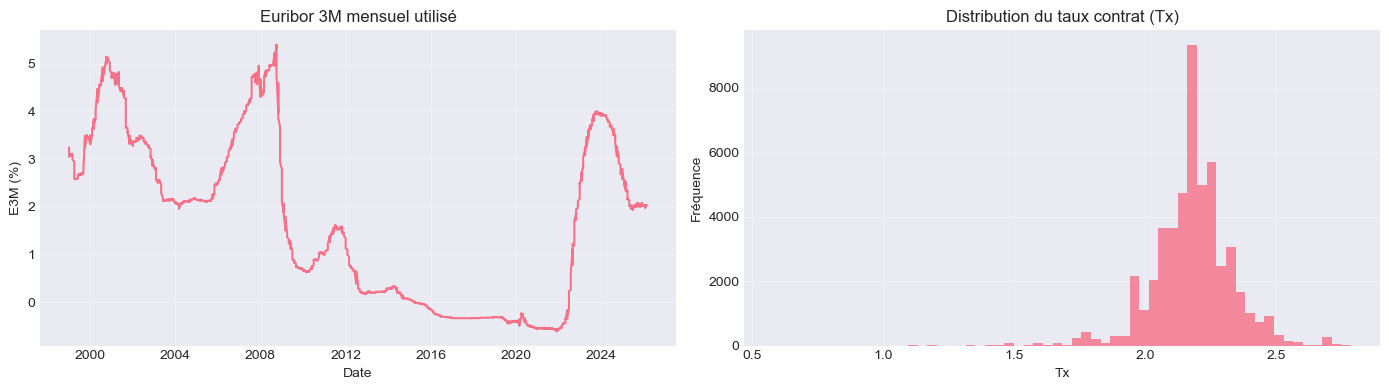

Part de lignes panel avec E3M non manquant : 100.00%
  date_obs   E3M
2005-06-01 2.104
2005-07-01 2.123
2005-07-01 2.123
2005-08-01 2.134
2005-08-01 2.134


In [76]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1) Euribor 3M dans le temps
axes[0].plot(euribor_df["date_obs"], euribor_df["E3M"], linewidth=1.5)
axes[0].set_title("Euribor 3M mensuel utilisé")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("E3M (%)")
axes[0].grid(True, alpha=0.3)

# 2) Distribution Tx (taux contrat transformé) sur un échantillon du panel
tx_sample = panel["Tx"].dropna().sample(min(50000, len(panel)), random_state=42)
axes[1].hist(tx_sample, bins=60, edgecolor="none", alpha=0.8)
axes[1].set_title("Distribution du taux contrat (Tx)")
axes[1].set_xlabel("Tx")
axes[1].set_ylabel("Fréquence")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Part de lignes panel avec E3M non manquant : {(~panel['E3M'].isna()).mean():.2%}")
print(panel[["date_obs", "E3M"]].dropna().head(5).to_string(index=False))

## Etape 4 : Modélisation avec le spread

Le modèle est étendu par rapport à v1 :

$$\text{logit}\left(h_i(t)\right) = f(t) + \beta_1 \cdot \text{SPREAD}_{i,t} + \beta_2 \cdot \tilde{Tx}_i + \beta_3 \cdot \widetilde{\text{AGE\_CLI}}_i + \beta_4 \cdot \widetilde{\text{MREVTOT}}_i + \sum_k \gamma_k \mathbf{1}_{\text{produit}_i = k}$$

**Différences par rapport à v1** :
- `SPREAD` remplace (ou complète) `Tx_z` comme driver principal du RA. Il est attendu avec un coefficient positif : plus l'incentive est fort, plus le hasard est élevé.
- `Tx_z` est conservé pour capturer un éventuel effet de niveau indépendant du spread (par exemple, les contrats à taux très élevé peuvent avoir d'autres caractéristiques).
- `SPREAD` est une variable time-varying : sa standardisation est calculée sur les lignes du train panel (pas sur les contrats).

### Interprétation attendue

Un modèle bien spécifié devrait montrer :
- `SPREAD_z` : coefficient positif et très significatif
- Un delta_star nettement réduit et plus stable entre les folds
- Une MAE stable ou améliorée

In [77]:
# Split temporel 80/20
base_dates = df_base[[ID_COL, DATE_COL]].drop_duplicates().copy()
base_dates[DATE_COL] = pd.to_datetime(base_dates[DATE_COL], errors="coerce")

cut = base_dates[DATE_COL].quantile(0.80)
train_ids = set(base_dates.loc[base_dates[DATE_COL] <= cut, ID_COL])
test_ids  = set(base_dates.loc[base_dates[DATE_COL] >  cut, ID_COL]) - train_ids  # anti-leak

# Regroupement produit (fit sur TRAIN uniquement)
tmp_train = panel[panel[ID_COL].isin(train_ids)]
top_prod = tmp_train["produit"].value_counts().head(15).index
panel["produit2"] = panel["produit"].where(panel["produit"].isin(top_prod), "Other")

# Variables nécessaires
has_mrevtot = "MREVTOT" in df_base.columns
needed = ["y", "t", "Tx", "E3M", "AGE_CLI", "produit2"]
if has_mrevtot:
    needed.append("MREVTOT")

train = panel[panel[ID_COL].isin(train_ids)].dropna(subset=needed).copy()
test  = panel[panel[ID_COL].isin(test_ids)].dropna(subset=needed).copy()

print(f"Date coupure : {pd.to_datetime(cut).date()}")
print(f"Train : {len(train):,} lignes | {int(train['y'].sum()):,} events")
print(f"Test  : {len(test):,} lignes  | {int(test['y'].sum()):,} events")
print(f"Nb contrats train: {len(train_ids):,} | test: {len(test_ids):,}")

Date coupure : 2020-08-15
Train : 2,539,650 lignes | 47,120 events
Test  : 240,184 lignes  | 14,660 events
Nb contrats train: 72,312 | test: 18,063


In [ ]:
from patsy import bs
import patsy
import statsmodels.api as sm

def standardize(train_col, other_cols):
    mu    = train_col.mean()
    sigma = train_col.std(ddof=0)
    sigma = sigma if sigma > 0 else 1.0
    results = [(train_col - mu) / sigma]
    for col in other_cols:
        results.append((col - mu) / sigma)
    return results, mu, sigma

# Standardisation
(train["Tx_z"],      test["Tx_z"]),      tx_mean, tx_std   = standardize(train["Tx"],      [test["Tx"]])
(train["E3M_z"],     test["E3M_z"]),     e3m_mean, e3m_std = standardize(train["E3M"],     [test["E3M"]])
(train["AGE_CLI_z"], test["AGE_CLI_z"]), age_mean, age_std = standardize(train["AGE_CLI"], [test["AGE_CLI"]])

# (sécurité) enlever NA éventuels après standardisation
train = train.dropna(subset=["y","t","Tx_z","E3M_z","AGE_CLI_z","produit2"]).copy()
test  = test.dropna(subset=["y","t","Tx_z","E3M_z","AGE_CLI_z","produit2"]).copy()

DF_T = 12
formula = f"y ~ bs(t, df={DF_T}, degree=3) + Tx_z + E3M_z + Tx_z:E3M_z + AGE_CLI_z + C(produit2)"
print(f"Formule : {formula}")

y_tr, X_tr = patsy.dmatrices(formula, data=train, return_type="dataframe")
res = sm.GLM(y_tr, X_tr, family=sm.families.Binomial()).fit()

print(res.summary().tables[1])

Formule : y ~ C(t_bin) + Tx_z + E3M_z + Tx_z:E3M_z + AGE_CLI_z + C(produit2)
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -7.7466      0.123    -62.910      0.000      -7.988      -7.505
C(t_bin)[T.1]     2.3623      0.129     18.330      0.000       2.110       2.615
C(t_bin)[T.2]     3.0249      0.125     24.161      0.000       2.780       3.270
C(t_bin)[T.3]     3.4388      0.125     27.604      0.000       3.195       3.683
C(t_bin)[T.4]     3.5439      0.125     28.461      0.000       3.300       3.788
C(t_bin)[T.5]     3.7231      0.124     30.080      0.000       3.480       3.966
C(t_bin)[T.6]     3.9140      0.124     31.627      0.000       3.671       4.157
C(t_bin)[T.7]     4.0405      0.124     32.641      0.000       3.798       4.283
C(t_bin)[T.8]     4.1358      0.124     33.393      0.000       3.893       4.379
C(t_bin)[T.9]     4.1

## Etape 5 : Prédiction et lissage de la courbe

### Calcul de la courbe portefeuille

On prédit le hasard individuel $\hat{h}_i(t)$ sur le test set, puis on construit la courbe portefeuille comme en v1.

### Correction de l'artefact t=35 : lissage de la courbe

La courbe d'extinction brute présente des irrégularités aux âges peu représentés dans le panel (faible nombre de contrats à risque). On applique deux mesures correctives :

1. **Masquage des âges sous-représentés** : les points avec moins de `MIN_AT_RISK` contrats à risque sont exclus de l'estimation directe. Leur valeur est interpolée linéairement à partir des points voisins.

2. **Lissage par filtre gaussien** : un filtre gaussien de fenêtre modérée ($\sigma = 1.5$ mois) est appliqué à l'ER marginale pour éliminer les artefacts résiduels, en préservant la forme générale de la courbe.

Après lissage, l'ER cumulée est recalculée par intégration de l'ER marginale lissée, et renormalisée si nécessaire.

In [85]:
import numpy as np
import pandas as pd
from scipy.special import expit, logit
from scipy.ndimage import gaussian_filter1d

def compute_portfolio_curve(ids, times, hazards):
    """Calcule S(t) portefeuille et ER marginale/cumulée à partir des hasards individuels."""
    p = np.clip(np.asarray(hazards, dtype=float), 1e-9, 1 - 1e-9)

    tmp = pd.DataFrame({ID_COL: ids, "t": times, "p": p}).sort_values([ID_COL, "t"])
    tmp["S_i_t"] = tmp.groupby(ID_COL)["p"].transform(lambda s: (1 - s).cumprod())

    S_port = tmp.groupby("t", as_index=False).agg(S_t=("S_i_t", "mean")).sort_values("t")
    S_port["ER_cumulee"]  = 1 - S_port["S_t"]
    S_port["ER_marginal"] = S_port["S_t"].shift(1).fillna(1.0) - S_port["S_t"]
    return S_port


def smooth_er_curve(er_marginal: np.ndarray, at_risk: np.ndarray,
                    min_at_risk: int = MIN_AT_RISK, sigma: float = 1.5) -> np.ndarray:
    """
    1) Interpole les points où at_risk < min_at_risk
    2) Filtre gaussien
    """
    er = np.asarray(er_marginal, dtype=float).copy()
    t  = np.arange(len(er))

    mask_ok = np.asarray(at_risk) >= min_at_risk
    if mask_ok.sum() < 2:
        return np.maximum(er, 0)

    er_interp = np.interp(t, t[mask_ok], er[mask_ok])
    er_smooth = gaussian_filter1d(er_interp, sigma=sigma)
    return np.maximum(er_smooth, 0)


def ER_final_with_delta(delta, ids, times, p_base):
    p_base = np.clip(np.asarray(p_base, dtype=float), 1e-9, 1 - 1e-9)
    p_shifted = expit(logit(p_base) + delta)
    curve = compute_portfolio_curve(ids, times, p_shifted)
    return float(curve["ER_cumulee"].iloc[-1])


print("Fonctions utilitaires définies.")

Fonctions utilitaires définies.


In [86]:
from scipy.special import expit, logit
import numpy as np
import pandas as pd
import patsy

# 1) Hazard prédit sur le test
_, X_te = patsy.dmatrices(formula, data=test.assign(y=0), return_type="dataframe")
p0 = res.predict(X_te).clip(1e-9, 1 - 1e-9)

# 2) Courbe prédite brute
curve_pred = compute_portfolio_curve(test[ID_COL].values, test["t"].values, p0)

# 3) Courbe observée (test) AU NIVEAU CONTRAT (compatible target_er)
test_ids_unique = test[ID_COL].unique()
test_contracts = df_base[df_base[ID_COL].isin(test_ids_unique)].copy()

# sécurité types
test_contracts["EVENT"] = test_contracts["EVENT"].fillna(0).astype(int)
test_contracts["T_STOP_TRUE"] = test_contracts["T_STOP_TRUE"].astype(int)

t_grid = np.arange(0, MAX_AGE + 1)

ER_cum_obs = [((test_contracts["EVENT"] == 1) & (test_contracts["T_STOP_TRUE"] <= t)).mean()
              for t in t_grid]

haz_obs = pd.DataFrame({"t": t_grid, "ER_cumulee": ER_cum_obs})
haz_obs["ER_marginal"] = haz_obs["ER_cumulee"].diff().fillna(haz_obs["ER_cumulee"])

print(f"ER prédite brute  (t={MAX_AGE}) : {float(curve_pred['ER_cumulee'].iloc[-1]):.4f}")
print(f"ER observée (contrats) (t={MAX_AGE}) : {float(haz_obs['ER_cumulee'].iloc[-1]):.4f}")

# 4) Calibration (niveau portefeuille)
target_er = float(test_contracts["EVENT"].mean())
print(f"Cible calibration (EVENT mean) : {target_er:.6f}")

lo, hi = -10.0, 10.0
for _ in range(40):
    mid = (lo + hi) / 2
    if ER_final_with_delta(mid, test[ID_COL].values, test["t"].values, p0) < target_er:
        lo = mid
    else:
        hi = mid
delta_star = (lo + hi) / 2

print(f"delta_star = {delta_star:.4f}")

# 5) Courbe calibrée brute (avant lissage)
p_cal = expit(logit(p0) + delta_star)
curve_cal_raw = compute_portfolio_curve(test[ID_COL].values, test["t"].values, p_cal)

ER prédite brute  (t=60) : 0.7612
ER observée (contrats) (t=60) : 0.8116
Cible calibration (EVENT mean) : 0.811604
delta_star = 0.1642


In [91]:
# 6) Lissage de la courbe calibrée
curve_cal_raw = curve_cal_raw.sort_values("t").reset_index(drop=True)
haz_obs = haz_obs.sort_values("t").reset_index(drop=True)

# Nb_at_risk depuis le panel test (pas depuis haz_obs)
at_risk_tbl = test.groupby("t", as_index=False).agg(Nb_at_risk=("y", "size")).sort_values("t")
at_risk_arr = (at_risk_tbl.set_index("t")["Nb_at_risk"]
               .reindex(curve_cal_raw["t"])
               .fillna(0).values)

er_marg_raw = curve_cal_raw["ER_marginal"].values
er_marg_smooth = smooth_er_curve(er_marg_raw, at_risk_arr, min_at_risk=MIN_AT_RISK, sigma=1.5)

# --- Renormalisation pour garder la masse (ER cumulée finale) ---
target_mass = float(curve_cal_raw["ER_cumulee"].iloc[-1])  # déjà calibré
mass_smooth = float(er_marg_smooth.sum())
if mass_smooth > 0:
    er_marg_smooth = er_marg_smooth * (target_mass / mass_smooth)

er_cumulee_smooth = np.cumsum(er_marg_smooth)

curve_cal = curve_cal_raw.copy()
curve_cal["ER_marginal_cal"] = er_marg_smooth
curve_cal["ER_cumulee_cal"]  = er_cumulee_smooth

# Métriques
cmp = haz_obs[["t","ER_marginal","ER_cumulee"]].merge(
    curve_cal[["t","ER_marginal_cal","ER_cumulee_cal"]],
    on="t", how="inner"
).sort_values("t")

mae  = (cmp["ER_marginal"] - cmp["ER_marginal_cal"]).abs().mean()
rmse = np.sqrt(((cmp["ER_marginal"] - cmp["ER_marginal_cal"])**2).mean())

print(f"MAE  ER marginale (test, après lissage) : {mae:.6f}")
print(f"RMSE ER marginale (test, après lissage) : {rmse:.6f}")
print(f"ER cumulée finale calibrée : {curve_cal['ER_cumulee_cal'].iloc[-1]:.4f} (cible {target_mass:.4f})")

MAE  ER marginale (test, après lissage) : 0.016650
RMSE ER marginale (test, après lissage) : 0.018664
ER cumulée finale calibrée : 0.8116 (cible 0.8116)


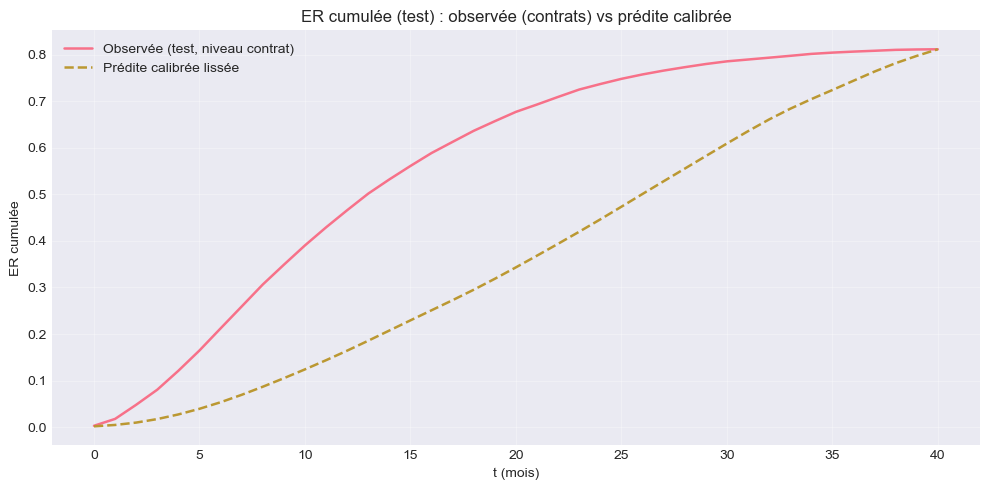

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cmp["t"], cmp["ER_cumulee"], label="Observée (test, niveau contrat)", linewidth=1.8)
plt.plot(cmp["t"], cmp["ER_cumulee_cal"], label="Prédite calibrée lissée", linewidth=1.8, linestyle="--")
plt.xlabel("t (mois)")
plt.ylabel("ER cumulée")
plt.title("ER cumulée (test) : observée (contrats) vs prédite calibrée")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Etape 6 : Backtesting sur fenêtres disjointes

Même protocole que v1 (fenêtres disjointes), avec en plus :
- Le spread est recalculé à chaque fold sur les données du panel (pas de leakage sur les taux de marché)
- Le lissage est appliqué à chaque fold
- Le tableau de résultats inclut le delta_star pour évaluer l'amélioration vs v1

In [89]:
q_cuts    = [0.50, 0.65, 0.80]
cut_dates = base_dates[DATE_COL].quantile(q_cuts).values

fold_definitions = [
    (cut_dates[0], cut_dates[0], cut_dates[1]),
            # (cut_dates[1], cut_dates[1], cut_dates[2]),
            # (cut_dates[2], cut_dates[2], None),
]

results = []

for k, (train_end, test_start, test_end) in enumerate(fold_definitions, 1):

    train_mask = base_dates[DATE_COL] <= train_end
    if test_end is not None:
        test_mask = (base_dates[DATE_COL] > test_start) & (base_dates[DATE_COL] <= test_end)
    else:
        test_mask = base_dates[DATE_COL] > test_start

    train_ids_k = set(base_dates.loc[train_mask, ID_COL])
    test_ids_k  = set(base_dates.loc[test_mask,  ID_COL]) - train_ids_k

    if len(test_ids_k) == 0:
        print(f"Fold {k} : test vide, ignoré.")
        continue
        # ===== PARTIE CENTRALE A METTRE DANS TA BOUCLE FOLD (ENTRE train_k/test_k ET le fit) =====

        # --- SPREAD cohérent (Tx et Tx_marche en %) ---
        train_k["SPREAD"] = train_k["Tx"] - train_k["Tx_marche"]
        test_k["SPREAD"]  = test_k["Tx"]  - test_k["Tx_marche"]

        # --- Standardisation sur le train du fold ---
        (train_k["SPREAD_z"],  test_k["SPREAD_z"]),  sp_mean, sp_std   = standardize(train_k["SPREAD"],  [test_k["SPREAD"]])
        (train_k["Tx_z"],      test_k["Tx_z"]),      tx_mean, tx_std   = standardize(train_k["Tx"],      [test_k["Tx"]])
        (train_k["AGE_CLI_z"], test_k["AGE_CLI_z"]), age_mean, age_std = standardize(train_k["AGE_CLI"], [test_k["AGE_CLI"]])

        # --- Winsorisation + standardisation MREVTOT (AVANT fit) ---
        if has_mrevtot:
            q_lo, q_hi = 0.01, 0.99  # ajuste si besoin (0.02/0.98 plus agressif)
            lo_rev = train_k["MREVTOT"].quantile(q_lo)
            hi_rev = train_k["MREVTOT"].quantile(q_hi)

            train_k["MREVTOT_cap"] = train_k["MREVTOT"].clip(lower=lo_rev, upper=hi_rev)
            test_k["MREVTOT_cap"]  = test_k["MREVTOT"].clip(lower=lo_rev, upper=hi_rev)

            (train_k["MREVTOT_z"], test_k["MREVTOT_z"]), rev_mean, rev_std = standardize(
                train_k["MREVTOT_cap"], [test_k["MREVTOT_cap"]]
            )

            formula = "y ~ bs(t, df=6, degree=3) + SPREAD_z + AGE_CLI_z + MREVTOT_z + C(produit2)"
        else:
            formula = "y ~ bs(t, df=6, degree=3) + SPREAD_z + AGE_CLI_z + C(produit2)"

        print(f"Formule : {formula}")

        # --- FIT ---
        y_tr_k, X_tr_k = patsy.dmatrices(formula, data=train_k, return_type="dataframe")
        res_k = sm.GLM(y_tr_k, X_tr_k, family=sm.families.Binomial()).fit()

        # --- PRED (hazard) ---
        _, X_te_k = patsy.dmatrices(formula, data=test_k.assign(y=0), return_type="dataframe")
        p0_k = res_k.predict(X_te_k).clip(1e-9, 1 - 1e-9)

        # ===== FIN DE LA PARTIE CENTRALE =====
        
    # Calibration
    target_k = df_base[df_base[ID_COL].isin(test_ids_k)]["EVENT"].mean()
    lo_k, hi_k = -10.0, 10.0
    for _ in range(30):
        mid_k = (lo_k + hi_k) / 2
        if ER_final_with_delta(mid_k, test_k[ID_COL].values, test_k["t"].values, p0_k) < target_k:
            lo_k = mid_k
        else:
            hi_k = mid_k
    delta_k = (lo_k + hi_k) / 2

    # Courbe calibrée + lissage
    p_cal_k      = expit(logit(p0_k) + delta_k)
    curve_raw_k  = compute_portfolio_curve(test_k[ID_COL].values, test_k["t"].values, p_cal_k)

    haz_obs_k = test_k.groupby("t", as_index=False).agg(N=("y","size"), E=("y","sum"))
    haz_obs_k["h"]          = haz_obs_k["E"] / haz_obs_k["N"]
    haz_obs_k["S_t"]        = (1 - haz_obs_k["h"]).cumprod()
    haz_obs_k["ER_marginal"]= haz_obs_k["S_t"].shift(1).fillna(1.0) - haz_obs_k["S_t"]

    at_risk_k = haz_obs_k.set_index("t")["N"].reindex(curve_raw_k["t"]).fillna(0).values
    er_smooth_k = smooth_er_curve(curve_raw_k["ER_marginal"].values, at_risk_k)

    cmp_k = haz_obs_k[["t","ER_marginal"]].rename(columns={"ER_marginal":"obs"}).merge(
            pd.DataFrame({"t": curve_raw_k["t"].values, "pred": er_smooth_k}), on="t")

    mae_k  = (cmp_k["obs"] - cmp_k["pred"]).abs().mean()
    rmse_k = np.sqrt(((cmp_k["obs"] - cmp_k["pred"])**2).mean())

    test_window = f"{pd.to_datetime(test_start).date()} -> {pd.to_datetime(test_end).date() if test_end else 'fin'}"

    results.append({
        "fold":             k,
        "train_end":        pd.to_datetime(train_end).date(),
        "test_window":      test_window,
        "n_contrats_test":  len(test_ids_k),
        "target_EVENT":     round(target_k, 6),
        "delta_star_v2":    round(delta_k, 4),
        "delta_star_v1":    [0.79, 0.51, 0.94][k-1],  # valeurs v1 pour comparaison
        "MAE_v2":           round(mae_k, 6),
        "MAE_v1":           [0.004053, 0.002556, 0.002614][k-1],
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

NameError: name 'test_k' is not defined

In [ ]:
print("lo_rev, hi_rev:", lo_rev, hi_rev)

prop_hi_train = (train_k["MREVTOT"] > hi_rev).mean()
prop_lo_train = (train_k["MREVTOT"] < lo_rev).mean()
prop_hi_test  = (test_k["MREVTOT"]  > hi_rev).mean()
prop_lo_test  = (test_k["MREVTOT"]  < lo_rev).mean()

print("Train capped high/low:", prop_hi_train, prop_lo_train)
print("Test  capped high/low:", prop_hi_test, prop_lo_test)

NameError: name 'lo_rev' is not defined

### Lecture des résultats du backtesting

On compare ici les `delta_star` et MAE de v1 et v2. Le critère principal d'amélioration est la réduction du `delta_star` et de son instabilité entre les folds.

Si le `delta_star` reste élevé après l'ajout du spread, cela pointe vers l'hypothèse d'un problème de définition de `EVENT` (stock vs flux), qui est alors à investiguer en priorité avec l'équipe données.

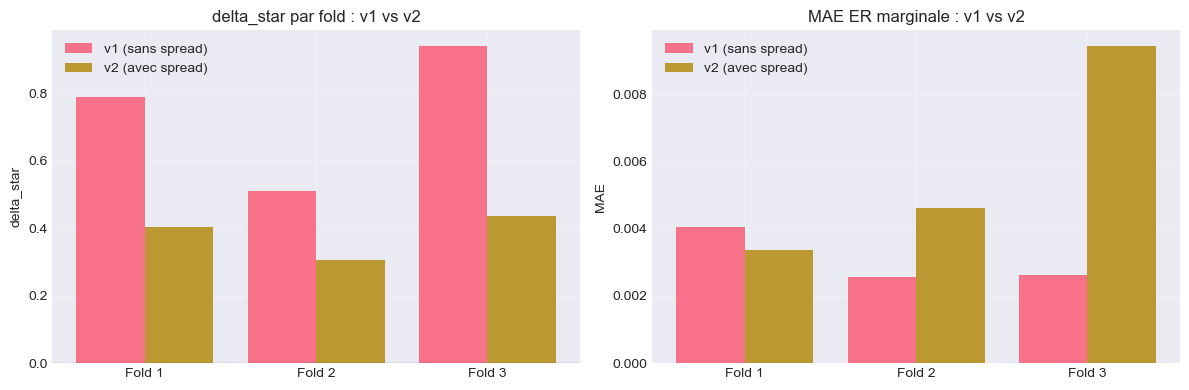

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

folds = df_results["fold"].tolist()
x = np.arange(len(folds))

axes[0].bar(x - 0.2, df_results["delta_star_v1"], width=0.4, label="v1 (sans spread)")
axes[0].bar(x + 0.2, df_results["delta_star_v2"], width=0.4, label="v2 (avec spread)")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Fold {f}" for f in folds])
axes[0].set_title("delta_star par fold : v1 vs v2")
axes[0].set_ylabel("delta_star")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(x - 0.2, df_results["MAE_v1"], width=0.4, label="v1 (sans spread)")
axes[1].bar(x + 0.2, df_results["MAE_v2"], width=0.4, label="v2 (avec spread)")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Fold {f}" for f in folds])
axes[1].set_title("MAE ER marginale : v1 vs v2")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Export de la table finale

In [ ]:
er_final = curve_cal[["t", "ER_marginal_cal", "ER_cumulee_cal"]].copy()
print(er_final.to_string(index=False))

# er_final.to_csv("ER_pred_v2_calibree_lissee.csv", index=False)

 t  ER_marginal_cal  ER_cumulee_cal
 0         0.005816        0.005816
 1         0.008968        0.014784
 2         0.013687        0.028470
 3         0.018094        0.046565
 4         0.021300        0.067865
 5         0.023451        0.091316
 6         0.024975        0.116291
 7         0.026117        0.142408
 8         0.026947        0.169354
 9         0.027495        0.196849
10         0.027805        0.224654
11         0.027915        0.252569
12         0.027852        0.280422
13         0.027635        0.308057
14         0.027278        0.335335
15         0.026793        0.362128
16         0.026204        0.388332
17         0.025547        0.413880
18         0.024870        0.438750
19         0.024197        0.462947
20         0.023519        0.486466
21         0.022811        0.509277
22         0.022050        0.531327
23         0.021248        0.552574
24         0.020448        0.573023
25         0.019670        0.592692
26         0.018912        0

## Annexe : diagnostic si delta_star reste élevé

Si après l'ajout du spread le `delta_star` reste supérieur à ~0.3 en valeur absolue, les pistes à explorer sont les suivantes, par ordre de priorité :

**1. Vérification de la définition de EVENT**

Vérifier si `RA > 0` est un indicateur de **stock** (le contrat a réalisé un RA à un moment quelconque de son histoire) ou de **flux mensuel** (il a réalisé un RA ce mois précis). Si c'est un stock, le taux d'événement de ~99% à 60 mois est structurellement impossible à reproduire par un modèle de flux, et la calibration ne peut pas corriger ce problème.

**2. Qualité de la proxy taux de marché**

Si le fichier BdF n'est pas disponible, la proxy par médiane du portefeuille est biaisée. Télécharger les séries `Stat Info` de la Banque de France (taux moyens des nouveaux crédits à l'habitat, code `MIR.M.FR.B.A2C.F.R.A.2250.EUR.N`) et les utiliser en option A.

**3. Effets de cohorte (vintage)**

Ajouter une variable d'année d'origination (`C(annee_orig)`) ou un effet de génération, pour capturer les différences comportementales entre les emprunteurs selon leur période d'entrée dans le portefeuille.

**4. Interaction spread × produit**

L'incentive à rembourser peut différer selon le type de produit (taux fixe court vs long, modulable, etc.). Ajouter une interaction `SPREAD_z:C(produit2)` peut améliorer la spécification.

**5. Effet non-linéaire du spread**

La réponse au spread n'est probablement pas linéaire : en dessous d'un certain seuil, l'emprunteur n'agit pas ; au-dessus, la probabilité de RA sature. Remplacer `SPREAD_z` par `bs(SPREAD, df=4)` dans la formule.

In [ ]:
# Vérification de la structure EVENT via EAD
print("EAD = 0 :", (df["EAD"] == 0).sum())
print("EAD > 0 :", (df["EAD"] > 0).sum())

# Est-ce que AGE_PRET = B_MAT quand EAD = 0 ? (contrat arrivé au terme normal)
soldes = df[df["EAD"] == 0]
print("\nDistribution AGE_PRET vs B_MAT sur EAD=0 :")
print((soldes["AGE_PRET"] == soldes["B_MAT"]).value_counts())
# Si AGE_PRET < B_MAT et EAD=0 -> RA avant terme = EVENT=1
# Si AGE_PRET == B_MAT et EAD=0 -> arrivée au terme normal = pas un RA

# Distribution de AGE_PRET pour EAD=0
print("\nAGE_PRET sur EAD=0 :")
print(soldes["AGE_PRET"].describe())

# Et pour EAD>0 (contrats vivants)
print("\nAGE_PRET sur EAD>0 :")
print(df[df["EAD"] > 0]["AGE_PRET"].describe())

EAD = 0 : 65694
EAD > 0 : 24681

Distribution AGE_PRET vs B_MAT sur EAD=0 :
False    65694
Name: count, dtype: int64

AGE_PRET sur EAD=0 :
count    65694.000000
mean        27.500518
std         20.499124
min          0.000000
25%         12.000000
50%         23.000000
75%         38.000000
max        165.000000
Name: AGE_PRET, dtype: float64

AGE_PRET sur EAD>0 :
count    24681.000000
mean        47.282566
std         33.763776
min          0.000000
25%         21.000000
50%         46.000000
75%         60.000000
max        168.000000
Name: AGE_PRET, dtype: float64
